In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Inspecting the scores a bit

In [18]:
dem_emotions_df = pd.read_csv('../data/emotion_scores/democrat_emails_emotions.csv')
df = pd.read_csv('../data/emotion_scores/emotion_scores_dcinbox_114.csv')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20582 entries, 0 to 20581
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            20582 non-null  object 
 1   first_name      20582 non-null  object 
 2   last_name       20582 non-null  object 
 3   subject         20581 non-null  object 
 4   id              20582 non-null  float64
 5   neutral_score   20485 non-null  float64
 6   anger_score     14623 non-null  float64
 7   joy_score       13675 non-null  float64
 8   disgust_score   5892 non-null   float64
 9   sadness_score   17661 non-null  float64
 10  surprise_score  16170 non-null  float64
 11  fear_score      14364 non-null  float64
dtypes: float64(8), object(4)
memory usage: 1.9+ MB


In [19]:
dcInbox = pd.read_csv('../data/dcInbox/dcinbox_export_114.csv')
unnamed_cols = dcInbox.columns.str.contains('^Unnamed')
dcInbox = dcInbox.loc[:, ~unnamed_cols].copy()
dcInbox = dcInbox[pd.to_numeric(dcInbox['Unix Timestamp'], errors='coerce').notna()].copy()
dcInbox['datetime'] = pd.to_datetime(dcInbox['Unix Timestamp'], unit='ms')

# Sort chronologically
dcInbox = dcInbox.sort_values('datetime').reset_index(drop=True)

# Filter data for February and March
# df = df[df['datetime'].between('2016-01-01', '2016-12-31')]
dcInbox = dcInbox[dcInbox['Chamber'] == 'House']
dcInbox.info()
# df = df.merge(dcInbox[['ID', 'Party']], on='id', how='left')



/var/folders/02/c1hvrmj11kx0z457p84l6pbc0000gn/T/ipykernel_48648/1879269009.py:1: DtypeWarning: Columns (2,4,10,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,25

<class 'pandas.core.frame.DataFrame'>
Index: 20582 entries, 3 to 24132
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Subject         20581 non-null  object        
 1   Body            20582 non-null  object        
 2   Unix Timestamp  20582 non-null  object        
 3   BioGuide ID     20582 non-null  object        
 4   Congress        20582 non-null  object        
 5   First Name      20582 non-null  object        
 6   Last Name       20582 non-null  object        
 7   Date of Birth   20582 non-null  object        
 8   Gender          20582 non-null  object        
 9   State           20582 non-null  object        
 10  District        20582 non-null  object        
 11  Party           20582 non-null  object        
 12  Chamber         20582 non-null  object        
 13  Nickname        1084 non-null   object        
 14  ID              20582 non-null  object        
 15  datetim

/var/folders/02/c1hvrmj11kx0z457p84l6pbc0000gn/T/ipykernel_48648/1879269009.py:5: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  dcInbox['datetime'] = pd.to_datetime(dcInbox['Unix Timestamp'], unit='ms')


In [20]:
mergedData = df.merge(dcInbox[['ID', 'Party']], left_on='id', right_on='ID', how='left')
mergedData = df.merge(dcInbox[['ID', 'Party']], left_on='id', right_on='ID', how='left')
mergedData = mergedData.drop('ID', axis=1) 
mergedData = mergedData.rename(columns={'Party': 'party'})
df = mergedData.copy()

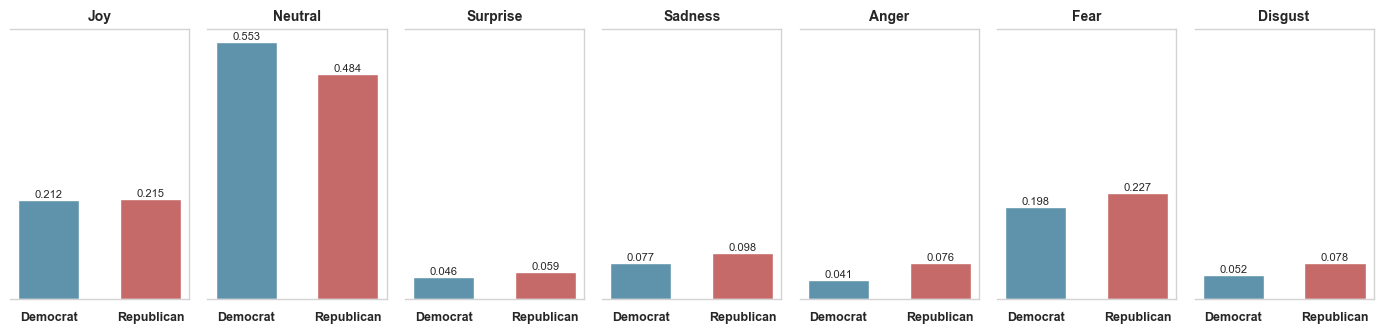

In [25]:
# Font settings
axis_titlesize = 10
axis_labelsize = 9
facet_titlesize = 9
caption_size = 8
ppt_axis_titlesize = 14
ppt_axis_labelsize = 14
ppt_facet_titlesize = 16
ppt_caption_size = 12
ppt_titlesize = 20

emotion_cols = ['joy_score', 'neutral_score', 'surprise_score', 
                'sadness_score', 'anger_score', 'fear_score', 'disgust_score']

# Convert to numeric (handle missing values)
for col in emotion_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Calculate average scores by party (ignoring NaN values)
party_emotions = df.groupby('party')[emotion_cols].mean()

# Prepare data for plotting
party_emotions_reset = party_emotions.reset_index()
party_emotions_melted = party_emotions_reset.melt(
    id_vars='party', 
    value_vars=emotion_cols,
    var_name='emotion',
    value_name='score'
)

# Clean up emotion names (remove _score suffix)
party_emotions_melted['emotion'] = party_emotions_melted['emotion'].str.replace('_score', '')

# Map party labels
party_labels = {"Democrat": "Democrats", "Republican": "Republicans"}
party_emotions_melted["party_label"] = party_emotions_melted["party"].map(party_labels)

dem_med_color = "#5F93AC"
rep_med_color = "#C66969"
party_colors = {"Democrat": dem_med_color, "Republican": rep_med_color}

sns.set(style="whitegrid")

g = sns.FacetGrid(
    party_emotions_melted,
    col="emotion",
    col_order=['joy', 'neutral', 'surprise', 'sadness', 'anger', 'fear', 'disgust'],
    height=4,
    aspect=0.5,  # narrower panels
    despine=False
)

# Replace facet titles and create bar plots
for ax, emotion in zip(g.axes.flat, ['joy', 'neutral', 'surprise', 'sadness', 'anger', 'fear', 'disgust']):
    emotion_data = party_emotions_melted[party_emotions_melted['emotion'] == emotion]
    
    # Create bar plot
    for idx, (party, color) in enumerate([("Democrat", dem_med_color), ("Republican", rep_med_color)]):
        party_data = emotion_data[emotion_data['party'] == party]
        score = party_data['score'].values[0]
        
        bar = ax.bar(idx, score, color=color, width=0.6)
        
        # Add value label on top
        ax.text(idx, score, f'{score:.3f}',
                ha='center', va='bottom', fontsize=caption_size)
    
    # Set title (emotion name)
    ax.set_title(emotion.capitalize())
    
    # Remove y-axis
    ax.set_ylabel('')
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    
    # Set x-axis labels to party names
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Democrat', 'Republican'], fontsize=axis_labelsize, fontweight='bold')
    ax.set_xlabel('')
    
    # Keep light gray spines for remaining edges
    for spine in ['right', 'top', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color("lightgray")
        ax.spines[spine].set_linewidth(1)
    
    # Remove grid
    ax.grid(False)

# No axis labels needed
g.set_axis_labels("", "")

# Force figure size
g.fig.set_size_inches(14, 3.5)

# Style titles
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelsize=axis_labelsize)
    ax.title.set_fontweight("bold")
    ax.title.set_fontsize(axis_titlesize)
    ax.title.set_position((0.5, 1.05))

plt.tight_layout()
plt.savefig('../figures/emotion_scores/average_emotion_scores.png', dpi=300, bbox_inches='tight')
plt.show()


Democrat - Emails above thresholds:
threshold  0.25-0.50  0.50-0.75  >0.75
emotion                               
anger             29          6     14
disgust           12          5      1
fear             136        104    160
joy              208        169    134
neutral          372        447    910
sadness           73         51     46
surprise          15          6      0


Republican - Emails above thresholds:
threshold  0.25-0.50  0.50-0.75  >0.75
emotion                               
anger            202         82     58
disgust           96         25     28
fear             404        326    489
joy              479        316    285
neutral          973       1077   1776
sadness          217        132    165
surprise          85         30     28



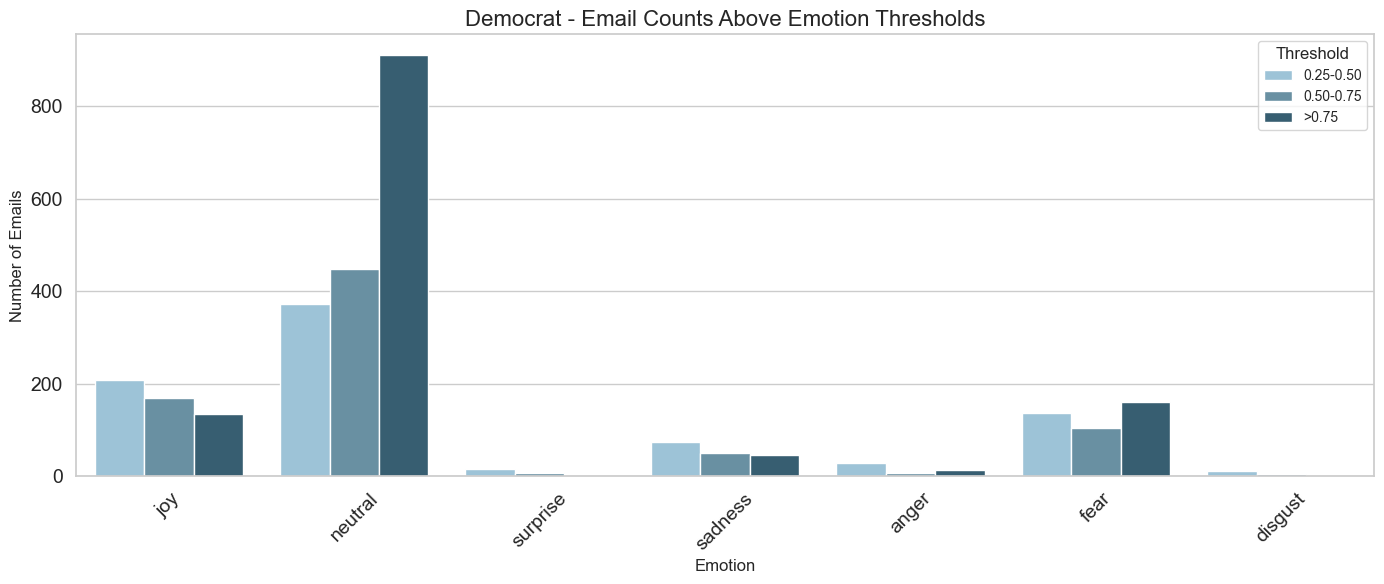

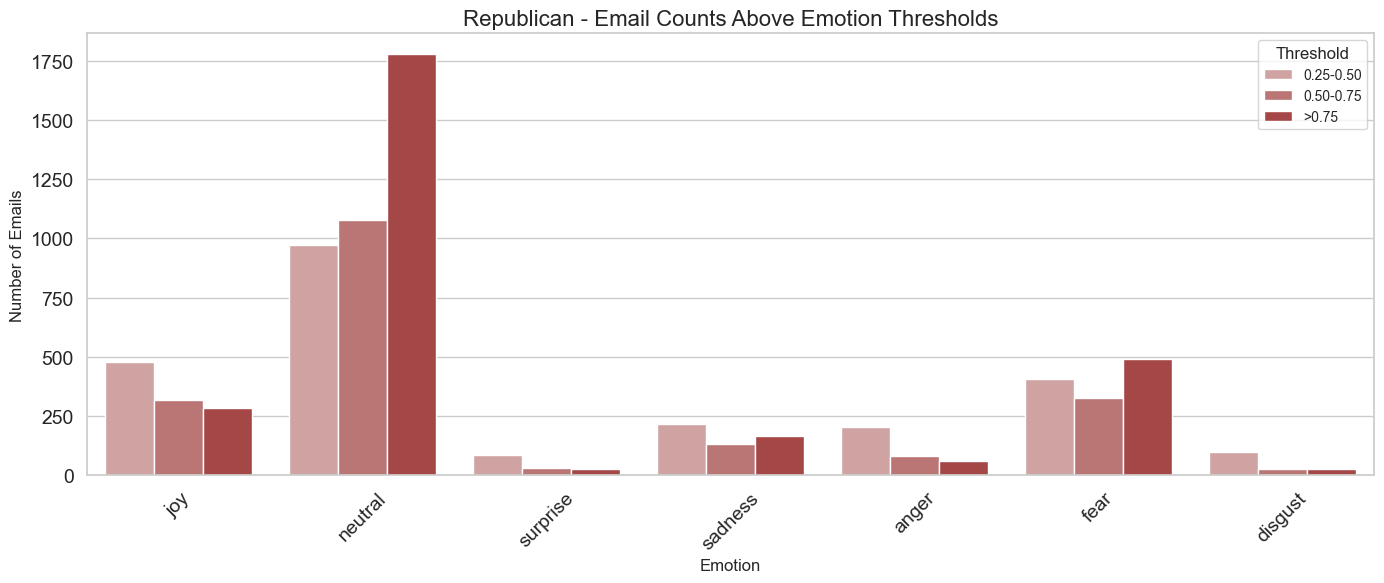

In [14]:
# Emotion columns
emotion_cols = ['joy_score', 'neutral_score', 'surprise_score', 
                'sadness_score', 'anger_score', 'fear_score', 'disgust_score']

# Convert to numeric (handle missing values)
for col in emotion_cols:
    mergedData[col] = pd.to_numeric(mergedData[col], errors='coerce')

# Define thresholds
thresholds = [0.25, 0.50, 0.75]

# Define colors
overall_color = "#acacac"
dem_light_color = "#93C6E1"
rep_light_color = "#D79C9C"
dem_med_color = "#5F93AC"
rep_med_color = "#C66969"
dem_dark_color = "#2E627A"
rep_dark_color = "#B53737"

# Palette for thresholds (light = >0.25, medium = >0.50, dark = >0.75)
party_palettes = {
    'Democrat': {'0.25-0.50': dem_light_color, '0.50-0.75': dem_med_color, '>0.75': dem_dark_color},
    'Republican': {'0.25-0.50': rep_light_color, '0.50-0.75': rep_med_color, '>0.75': rep_dark_color}
}


def count_above_thresholds(data, emotion_cols, thresholds):
    results = []
    for emotion in emotion_cols:
        # Count emails in exclusive ranges
        # 0.25 < score <= 0.50
        count_low = ((data[emotion] > 0.25) & (data[emotion] <= 0.50)).sum()
        results.append({
            'emotion': emotion.replace('_score', ''),
            'threshold': '0.25-0.50',
            'count': count_low
        })
        
        # 0.50 < score <= 0.75
        count_mid = ((data[emotion] > 0.50) & (data[emotion] <= 0.75)).sum()
        results.append({
            'emotion': emotion.replace('_score', ''),
            'threshold': '0.50-0.75',
            'count': count_mid
        })
        
        # score > 0.75
        count_high = (data[emotion] > 0.75).sum()
        results.append({
            'emotion': emotion.replace('_score', ''),
            'threshold': '>0.75',
            'count': count_high
        })
    
    return pd.DataFrame(results)


# Create plots for each party
parties = ['Democrat', 'Republican']

for party in parties:
    # Filter data for this party
    party_data = mergedData[mergedData['party'] == party]
    
    # Count emails above thresholds
    threshold_counts = count_above_thresholds(party_data, emotion_cols, thresholds)
    
    # Create plot
    plt.figure(figsize=(14, 6))
    ax = sns.barplot(
        data=threshold_counts,
        x='emotion',
        y='count',
        hue='threshold',
        palette=party_palettes[party]
    )
    
    plt.title(f'{party} - Email Counts Above Emotion Thresholds', 
              fontsize=16)
    plt.xlabel('Emotion', fontsize=12)
    plt.ylabel('Number of Emails', fontsize=12)
    plt.legend(title='Threshold', fontsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Save the plot
    plt.savefig(f'../figures/emotion_scores/{party}_emotion_score_breakdown.png', dpi=300, bbox_inches='tight')
    
    # Print summary statistics
    print(f"\n{party} - Emails above thresholds:")
    print(threshold_counts.pivot(index='emotion', columns='threshold', values='count'))
    print()

plt.show()